# 05 Assess the Called Inversions
Visualizing the data was useful, but we need a more rigorous solution to evaluate the results. Specifically, we are interested in the false and true positive/negative rates for each of the treatments. Lets start with loading *all* the variants into a tidy table. We'll borrow the formatting code from `read_data()` used in the visualization steps, but it needs to be augmented to do _everything_ and label it all.

In [3]:
library(dplyr)
library(tidyr)
library(ggplot2)
options(warn = -1, repr.plot.width = 19, repr.plot.height = 10)

In [28]:
read_truth_data <- function(size_treatment){
    truthfile <- paste0("simulated_variants/inversions_genomes/", size_treatment, "/inv.", size_treatment,".vcf")

    true_inversions <- read.table(truthfile, header = F)[,c(1,2,8)]
    true_inversions$V8 <- as.numeric(unlist(lapply(true_inversions$V8, function(X){gsub(".+END=", "", X)})))
    names(true_inversions) <- c("contig", "position_start", "position_end")
    true_inversions$size <- size_treatment
    true_inversions <- group_by(true_inversions, contig) %>%
        mutate(id = 1:n())
    return(true_inversions[, c("contig", "id","size","position_start", "position_end")])
}

read_called_data <- function(size_treatment){
    called_df <- data.frame(
        sample = character(),
        contig = character(),
        size = character(),
        depth = character(),
        position_start = numeric(),
        position_end = numeric()
    )
    for(depth in c(0.5, 2, 5, 10, 20)){
        .depth <- paste("depth", depth, sep = "_")
        samplesfile <- paste("simulated_data/called_sv/leviathan", size_treatment, .depth, "by_sample90/inversions.bedpe", sep = "/")
        poolfile <- paste("simulated_data/called_sv/leviathan", size_treatment, .depth, "by_pop90/inversions.bedpe", sep = "/")

        sample_inversions <- read.table(
            samplesfile,
            header = T
        )[,1:4]
        if( nrow(sample_inversions) > 0){
            sample_inversions$size <- size_treatment
            sample_inversions$depth <- depth
            sample_inversions$sample <- gsub(pattern = "\\..*X", "", sample_inversions$sample)
        } else {
            sample_inversions$size <- character()
            sample_inversions$depth <- double()
        }

        pooled_inversions <- read.table(poolfile, header = T)
        pooled_inversions <- pooled_inversions[,c("population","contig", "position_start", "position_end")]
        names(pooled_inversions)[1] <- "sample"
        if( nrow(pooled_inversions) > 0){
            pooled_inversions$sample <- "pooled"
            pooled_inversions$size <- size_treatment
            pooled_inversions$depth <- depth
        } else {
            pooled_inversions$size <- character()
            pooled_inversions$depth <- character()
        }
        called_df <- rbind(called_df, sample_inversions, pooled_inversions)
    }

    return(called_df)
}

## Read in data
The assessment process is a little tricky, so let's start by having one dataframe of the known inversions and another of the called inversions. Using `Reduce(rbind, Map())` is going to make life a lot easier here.

### Known inversions

In [29]:
truthset <- Reduce(rbind, Map(read_truth_data, c("small","medium","large","xl")))
truthset <- data.frame(truthset)
head(truthset, 20)

,contig,id,size,position_start,position_end
,<chr>,<int>,<chr>,<int>,<dbl>
1,2L,1,small,3193196,3214221
2,2L,2,small,3940211,3944863
3,2L,3,small,13024404,13026577
4,2L,4,small,14845709,14861200
5,2L,5,small,20107901,20113695
6,2R,1,small,4328632,4333509
7,2R,2,small,9952840,9959287
8,2R,3,small,10569437,10578078
9,2R,4,small,11083686,11094907


### Called inversions
These are the inversions that `LEVIATHAN` called.

In [30]:
calledset <- Reduce(rbind, Map(read_called_data, c("small","medium","large","xl")))
calledset <- data.frame(calledset)
head(calledset, 20)

,sample,contig,position_start,position_end,size,depth
,<chr>,<chr>,<int>,<int>,<chr>,<dbl>
1,sample_06,2L,3940210,3944863,small,0.5
2,sample_05,2R,9952839,9959287,small,0.5
3,sample_10,3R,20081036,20093594,small,0.5
4,pooled,2L,3193195,3214220,small,0.5
5,pooled,2L,3940210,3944863,small,0.5
6,pooled,2L,14845708,14861200,small,0.5
7,pooled,2L,20107900,20113695,small,0.5
8,pooled,2R,9952839,9959287,small,0.5
9,pooled,2R,10569436,10578080,small,0.5


### Known sample inversions

I think it might make sense to do a fuzzy-match for the inversions for a given size treatment. Fuzzy in the sense that the start/end positions of the called inversions can be something like 1kb away and from the known breakpoint and still count.

Considerations:
- we are interested in the True/False Negative/Positive at all treatment levels
- not every sample has every simulated inversion.
  - we need to get the table of which samples have which inversions and cross-reference that to make sure that the presence/absence is actually true

In [31]:
inv_inventory <- read.table("inversion_simulations.inventory", header = T)
names(inv_inventory)[4] <- "id"
head(inv_inventory, 20)

,sample,size,contig,id,present,state
,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>
1,sample_01,small,2R,1,TRUE,het
2,sample_01,small,2R,2,TRUE,het
3,sample_01,small,2R,3,TRUE,het
4,sample_01,small,2R,4,TRUE,het
5,sample_01,small,2R,5,TRUE,het
6,sample_02,small,2R,1,TRUE,het
7,sample_02,small,2R,2,TRUE,het
8,sample_02,small,2R,3,TRUE,het
9,sample_02,small,2R,4,TRUE,het


We also need to add the pooled samples to this inventory

In [32]:
pool_inventory <- read.table("inversion_simulations.pool.inventory", header = T)
names(pool_inventory)[4] <- "id"
inv_inventory <- rbind(inv_inventory, pool_inventory)
tail(inv_inventory, 20)

,sample,size,contig,id,present,state
,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>
501,pool,medium,3R,1,TRUE,hom
502,pool,medium,3R,2,TRUE,hom
503,pool,medium,3R,3,TRUE,hom
504,pool,medium,3R,4,TRUE,hom
505,pool,medium,3L,1,TRUE,hom
506,pool,medium,3L,2,TRUE,hom
507,pool,medium,3L,3,TRUE,het
508,pool,medium,3L,4,TRUE,hom
509,pool,large,2R,1,TRUE,hom


We need to combine the inventory of samples' inversions (`inv_inventory`) with the known inversions themselves (`truthset`) to get an adequate table to iterate through. Doing a left join will give us that.

In [33]:
inv_inventory <- left_join(inv_inventory, truthset, by = c("contig","id", "size"))
head(inv_inventory, 15)

,sample,size,contig,id,present,state,position_start,position_end
,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<dbl>
1,sample_01,small,2R,1,TRUE,het,4328632,4333509
2,sample_01,small,2R,2,TRUE,het,9952840,9959287
3,sample_01,small,2R,3,TRUE,het,10569437,10578078
4,sample_01,small,2R,4,TRUE,het,11083686,11094907
5,sample_01,small,2R,5,TRUE,het,21736723,21759355
6,sample_02,small,2R,1,TRUE,het,4328632,4333509
7,sample_02,small,2R,2,TRUE,het,9952840,9959287
8,sample_02,small,2R,3,TRUE,het,10569437,10578078
9,sample_02,small,2R,4,TRUE,het,11083686,11094907


As a sanity check, see that there are indeed samples that do not have a vartiant

In [34]:
head(inv_inventory[!(inv_inventory$present),], 15)

,sample,size,contig,id,present,state,position_start,position_end
,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<dbl>
102,sample_01,small,3R,2,FALSE,NA,20081037,20093594
107,sample_02,small,3R,2,FALSE,NA,20081037,20093594
112,sample_03,small,3R,2,FALSE,NA,20081037,20093594
115,sample_03,small,3R,5,FALSE,NA,25379867,25402914
119,sample_04,small,3R,4,FALSE,NA,24971985,24984761
120,sample_04,small,3R,5,FALSE,NA,25379867,25402914
124,sample_05,small,3R,4,FALSE,NA,24971985,24984761
129,sample_06,small,3R,4,FALSE,NA,24971985,24984761
130,sample_06,small,3R,5,FALSE,NA,25379867,25402914


## Match called and known inversions

Next comes what should be a big loop that goes through rows of `inv_inventory` (an inversion for a sample) and checks `calledset` for if that inversion was called. We will need a nested loop that (outer loop) iterates through the depth treatments and an inner loop that iterates through the big inventory manifest (`inv_inventory`).

So now we loop through `inv_inventory` and try to match calls in `calledset`, adjusting the `count` column as necessary (booleans are easy to sum)

- check the `callset` for that inversion on that contig in that sample at that depth
  - if `inv_inventory$present` is `TRUE`, then and it **is** there, it's a TRUE POSITIVE
  - if `inv_inventory$present` is `TRUE`, then and it's **not** there, it's a FALSE NEGATIVE
  - if `inv_inventory$present` is `FALSE`, then and it **is** there, it's a FALSE POSITIVE
  - if `inv_inventory$present` is `FALSE`, then and it's **not** there, it's a TRUE NEGATIVE

all while doing a fuzzy match of 1 kbp

The `is_called()` function below will do all that. It takes a row from `inv_inventory` as input and will try to fuzzy-match the known inversion in the set of called inversions (`calledset`). One row goes in, but four rows get outputted (one row each for True/False Positive/Negative), and the resulting 4-row dataframe will be appended onto a growing results dataframe `assessment`. This 1-to-4 conversion makes the resulting dataframe in long-format, which will make math and plotting easier.

In [ ]:
is_called <- function(query_row, called_sv, depth_treatment, fuzzy_distance){
    # the vector returned corresponds to c(TP, FP, TN, FN)
    samplename <- query_row$sample
    sizeclass <- query_row$size
    # add padding to make the breakpoints more generous
    fuzzy_start <- query_row$position_start - fuzzy_distance
    fuzzy_end <- query_row$position_end + fuzzy_distance
    q_contig <- query_row$contig
    present <- query_row$present
    filtered_called <- filter(
        called_sv,
        sample == samplename,
        contig == q_contig,
        size == sizeclass,
        depth == depth_treatment,
        position_start >= fuzzy_start && position_end <= fuzzy_end
    )
    hits <- nrow(filtered_called)
    check_vec <- c(FALSE, FALSE, FALSE, FALSE)
    if(present){
        if(hits > 0){
            check_vec[1] <- TRUE
        } else {
            check_vec[4] <- TRUE
        }
    } else {
        if(hits > 0){
            check_vec[2] <- TRUE
        } else {
            check_vec[3] <- TRUE
        }
    }
    out_rows <- query_row[rep(1,4), ]
    out_rows$depth <- depth_treatment
    out_rows$assessment <- c("True Positive", "False Positive", "True Negative", "False Negative")
    out_rows$count <- check_vec
    return(out_rows)
}

In [36]:
depths <- c(0.5, 2.0, 5.0, 10.0, 20.0)
assessment <- data.frame(
    sample = character(),
    size = character(),
    contig = character(),
    id = integer(),
    present = logical(),
    state = character(),
    position_start = integer(),
    position_end = integer(),
    depth = character(),
    assessment = character(),
    count = logical()
)
for(.depth in depths){
    for(i in 1:nrow(inv_inventory)){
        results <- is_called(inv_inventory[i,], calledset, .depth , 1000)
        assessment <- rbind(assessment, results)
    }
}
assessment$depth <- factor(assessment$depth, levels = depths)
assessment$size <- factor(assessment$size, levels = c("small", "medium", "large", "xl"))
# fix pooled-sample state to hom to avoid NA
assessment$state[is.na(assessment$state)] <- "hom"
head(assessment)

,sample,size,contig,id,present,state,position_start,position_end,depth,assessment,count
,<chr>,<fct>,<chr>,<int>,<lgl>,<chr>,<int>,<dbl>,<fct>,<chr>,<lgl>
1,sample_01,small,2R,1,TRUE,het,4328632,4333509,0.5,True Positive,FALSE
1.1,sample_01,small,2R,1,TRUE,het,4328632,4333509,0.5,False Positive,FALSE
1.2,sample_01,small,2R,1,TRUE,het,4328632,4333509,0.5,True Negative,FALSE
1.3,sample_01,small,2R,1,TRUE,het,4328632,4333509,0.5,False Negative,TRUE
2,sample_01,small,2R,2,TRUE,het,9952840,9959287,0.5,True Positive,FALSE
2.1,sample_01,small,2R,2,TRUE,het,9952840,9959287,0.5,False Positive,FALSE


### Summarize by size-contig-depth
Given that the contigs themselves are also treatments, it might be useful to aggregate within the contigs for a depth treatment. We'll include an absolute count and a percent ratio, as that might be more informative.

In [37]:
assessment_by_contig <- group_by(assessment, size, contig, depth, assessment) %>%
    summarize_at("count", ~ sum(.x)) %>%
    group_by(size, contig, depth) %>%
    mutate(percent = round(count/sum(count) * 100,2))
head(assessment_by_contig)

size,contig,depth,assessment,count,percent
<fct>,<chr>,<fct>,<chr>,<int>,<dbl>
small,2L,0.5,False Negative,54,98.18
small,2L,0.5,False Positive,0,0.00
small,2L,0.5,True Negative,0,0.00
small,2L,0.5,True Positive,1,1.82
small,2L,2,False Negative,30,54.55
small,2L,2,False Positive,0,0.00


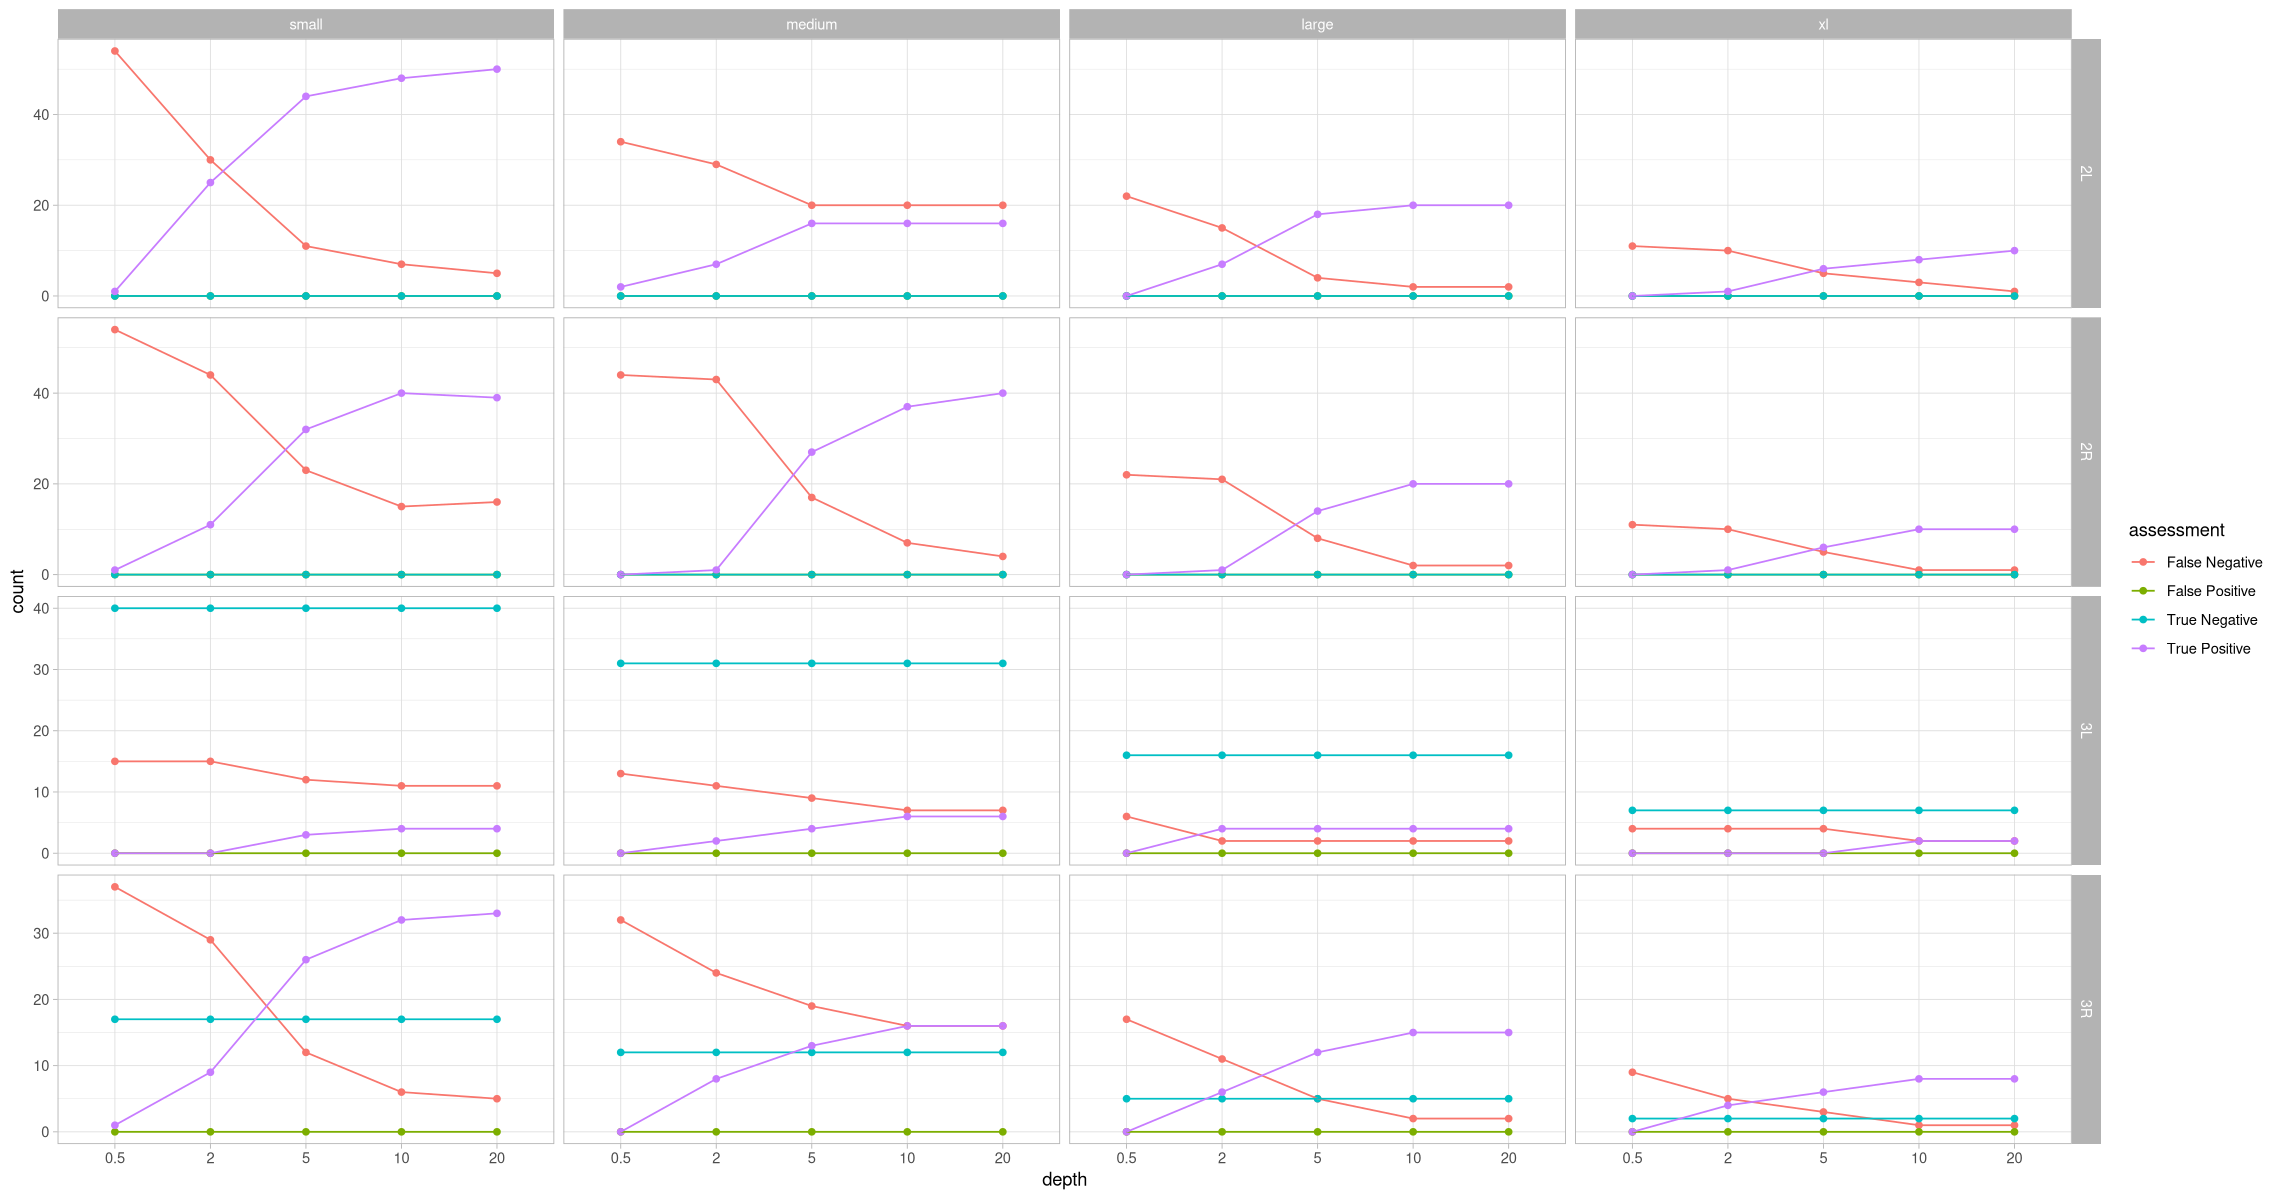

In [38]:
ggplot(assessment_by_contig, aes(x = depth, y = count, color = assessment, group = assessment)) +
    geom_point() +
    geom_line() +
    theme_light() +
    facet_grid(rows = vars(contig), cols = vars(size), scales = "free_y")

Let's plot it with percentages, which should be more revealing

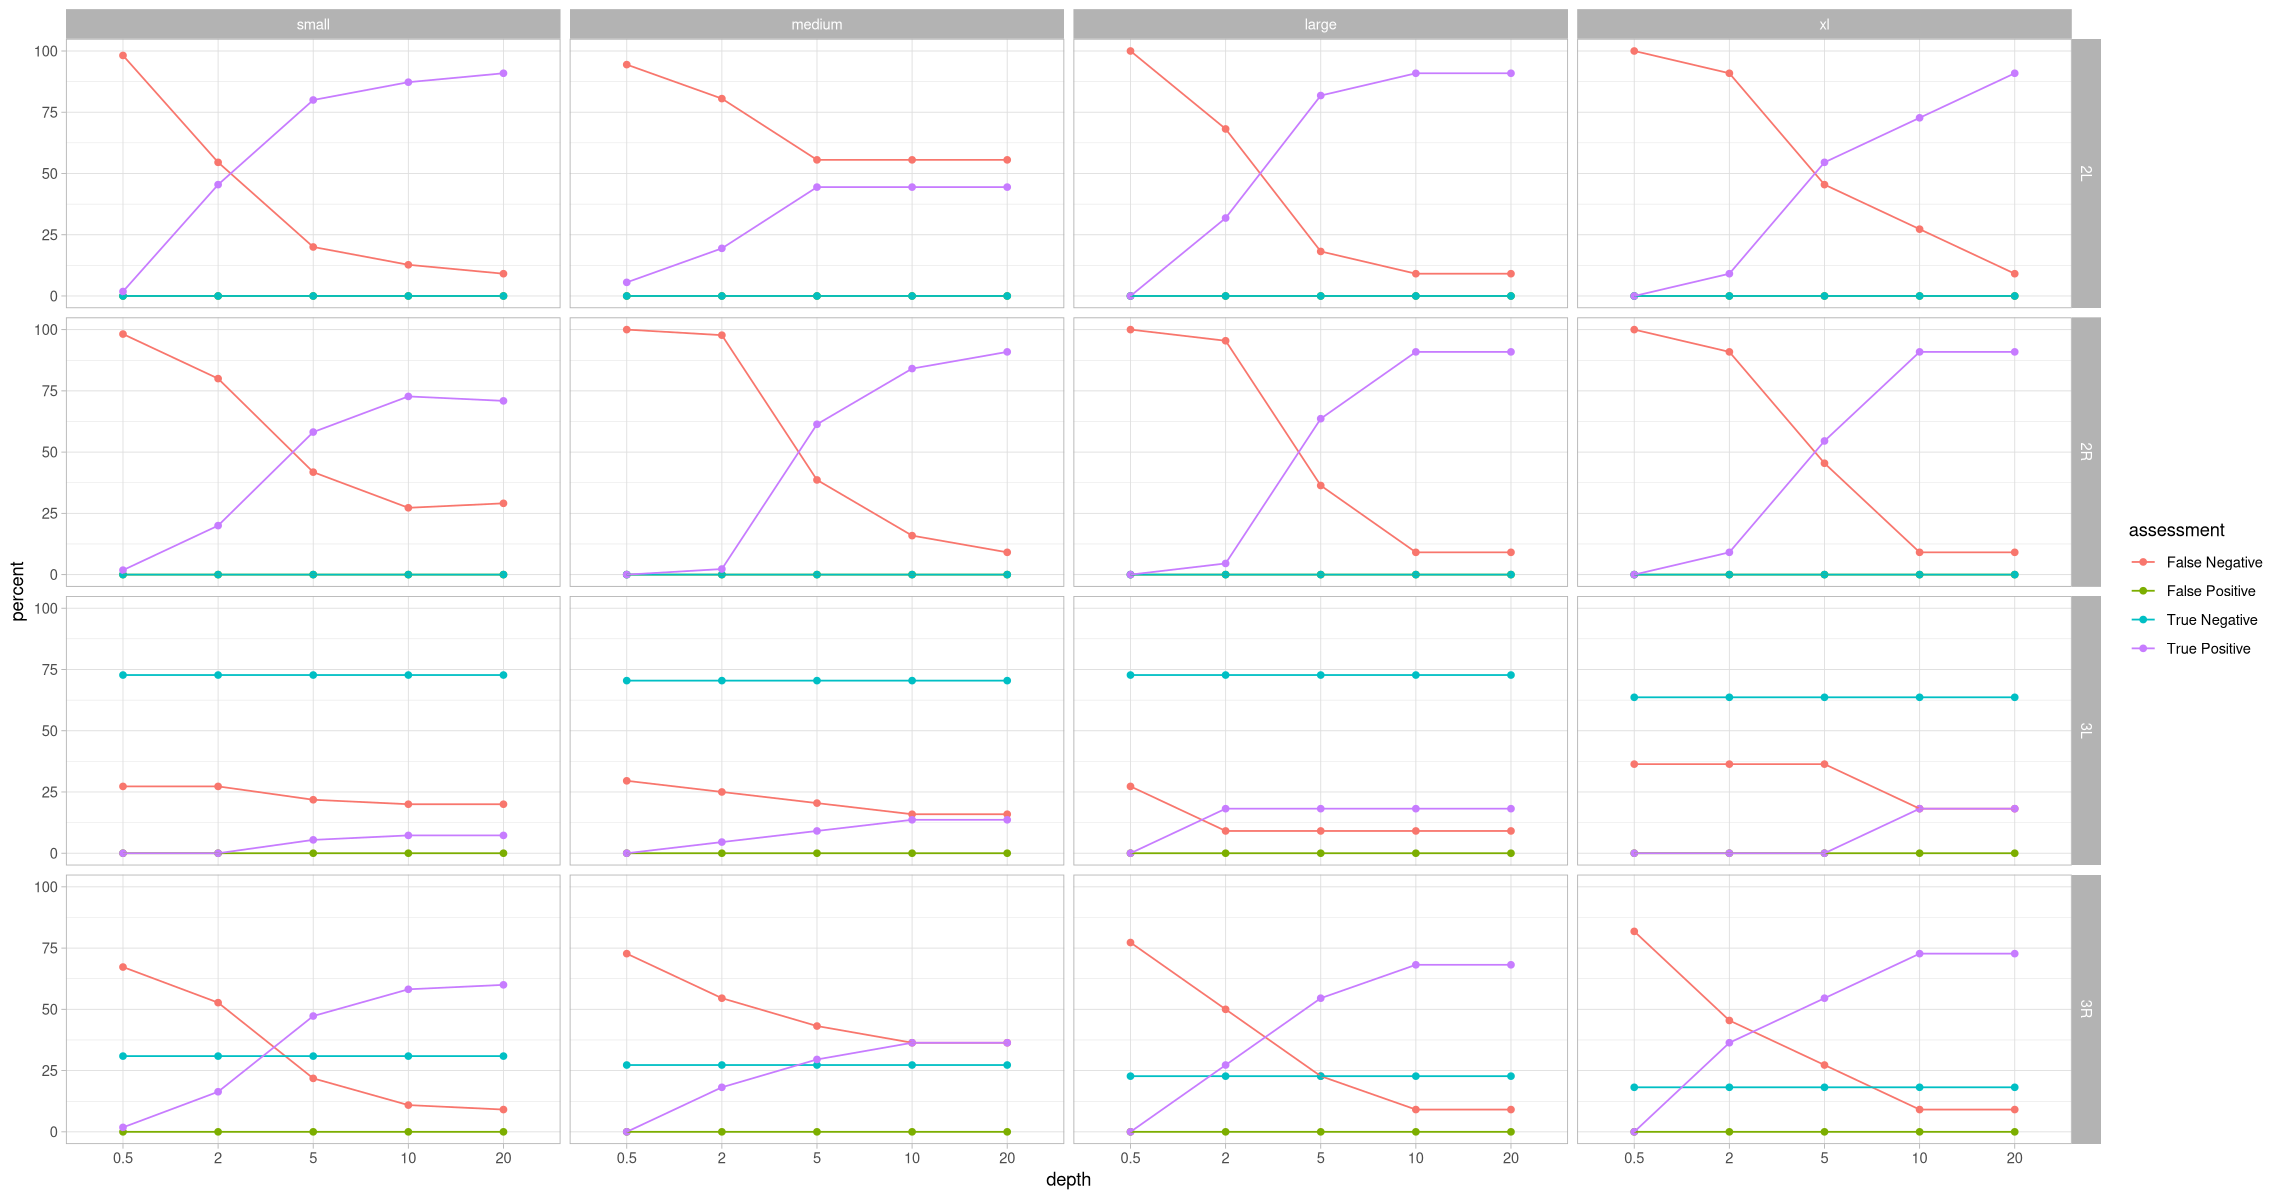

In [39]:
ggplot(assessment_by_contig, aes(x = depth, y = percent, color = assessment, group = assessment)) +
    geom_point() +
    geom_line() +
    theme_light() +
    facet_grid(rows = vars(contig), cols = vars(size))

### Summarize by zygosity

_Oh hey_, that's looking like something. Pretty exciting, actually. There are no false positives, which is great. What about what this looks like taking the zygosity into consideration? Let's also add a percent in addition to the absolute count.

In [40]:
assessment_by_contig_state <- group_by(assessment, size, state, contig, depth, assessment) %>% 
    summarize_at("count", ~ sum(.x)) %>%
    group_by(size, state, contig, depth) %>%
    mutate(percent = count/sum(count) * 100)
head(assessment_by_contig_state)

size,state,contig,depth,assessment,count,percent
<fct>,<chr>,<chr>,<fct>,<chr>,<int>,<dbl>
small,het,2R,0.5,False Negative,50,98.039216
small,het,2R,0.5,False Positive,0,0.000000
small,het,2R,0.5,True Negative,0,0.000000
small,het,2R,0.5,True Positive,1,1.960784
small,het,2R,2,False Negative,40,78.431373
small,het,2R,2,False Positive,0,0.000000


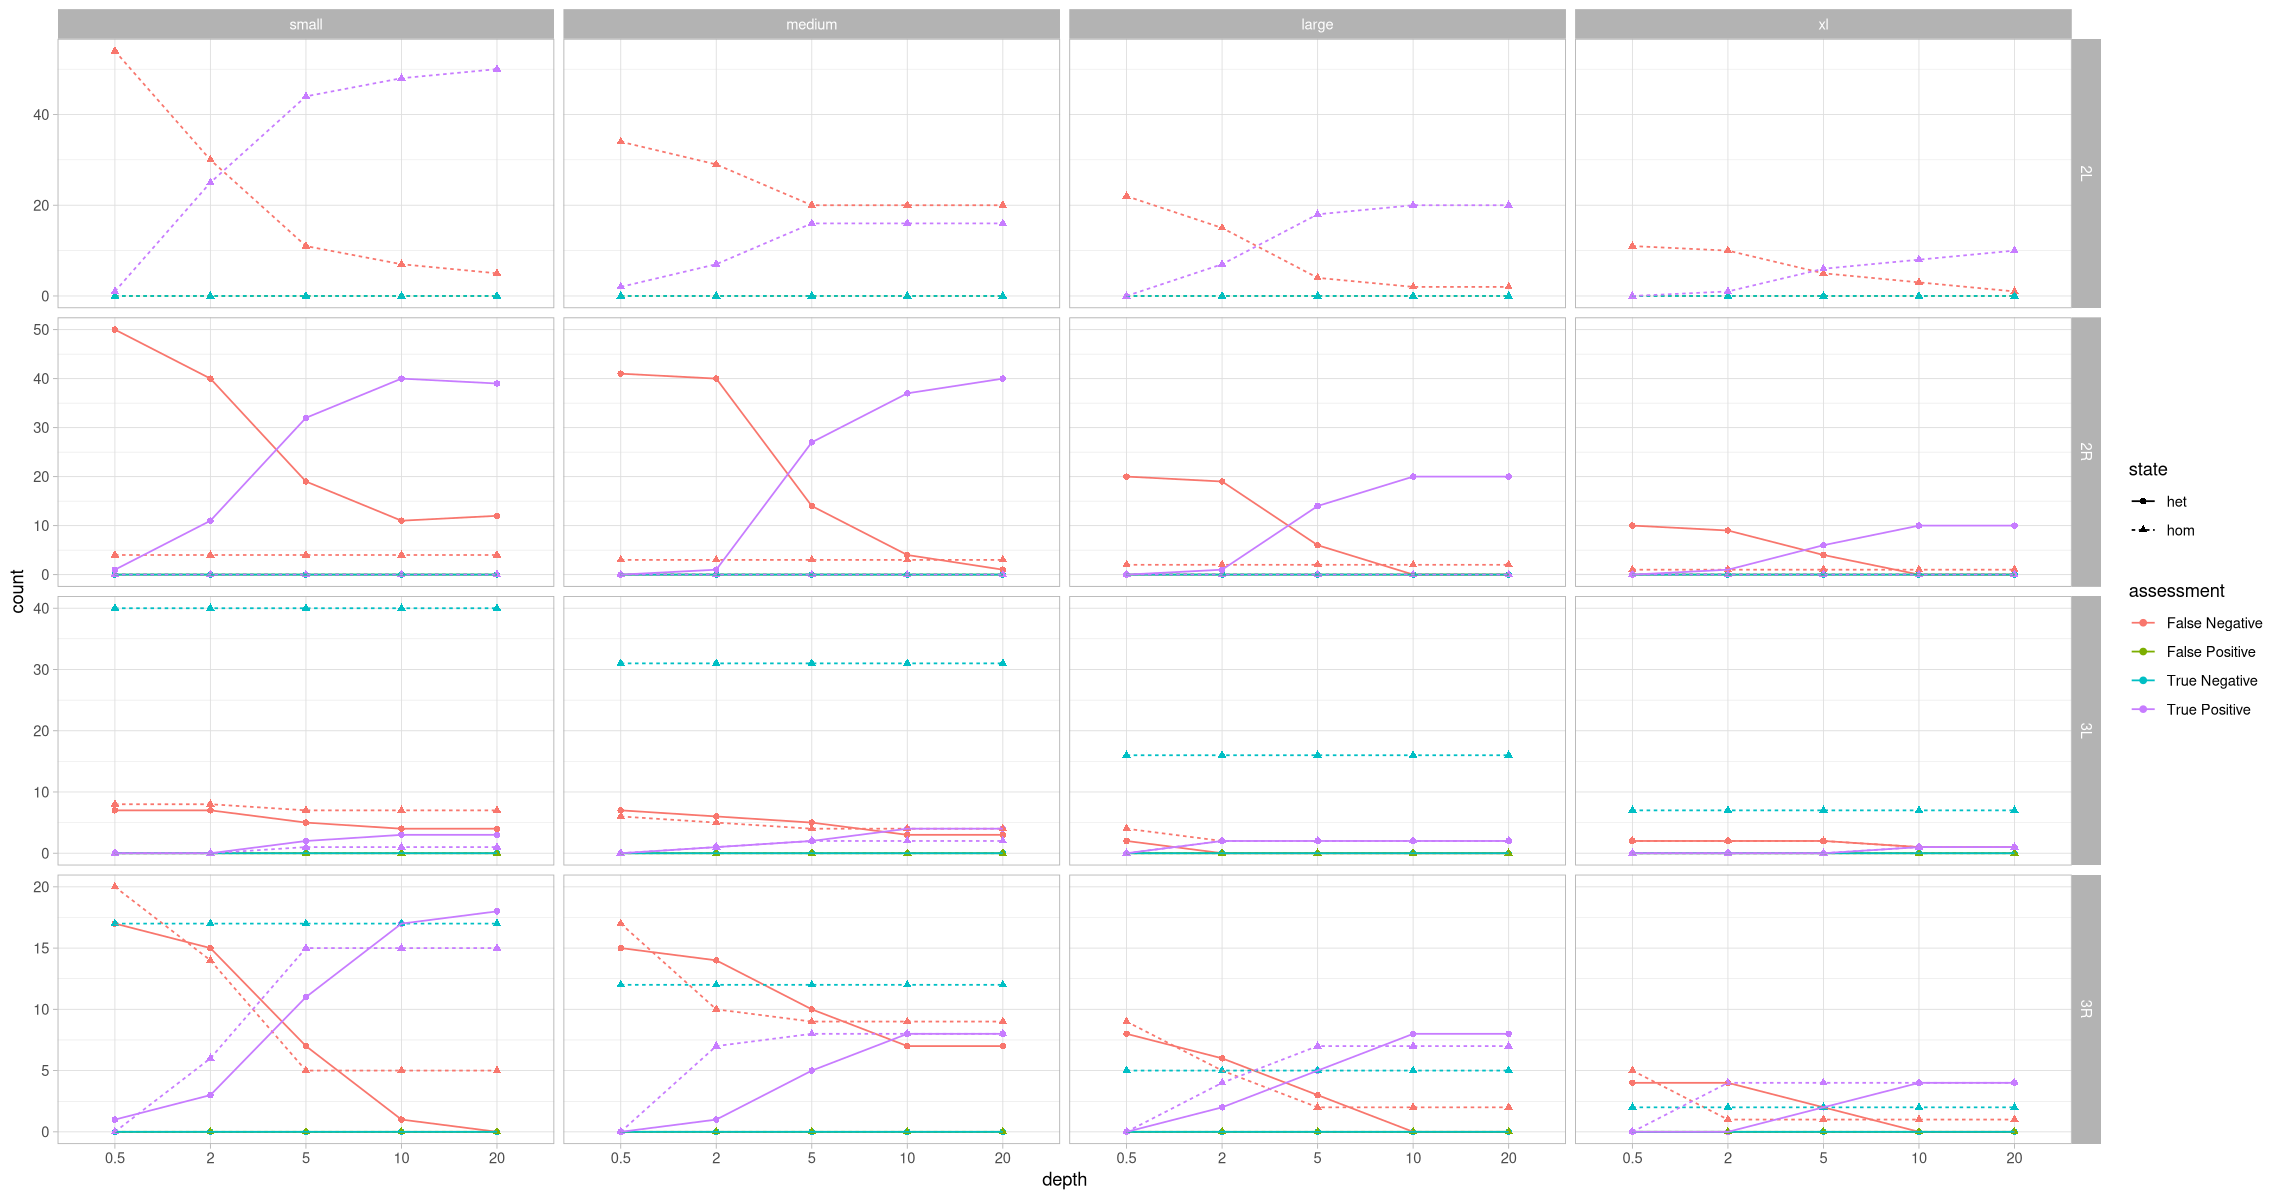

In [41]:
ggplot(assessment_by_contig_state, aes(x = depth, y = count, color = assessment, shape = state, group = paste(assessment, state))) +
    geom_point() +
    geom_line(aes(linetype = state)) +
    theme_light() +
    facet_grid(rows = vars(contig), cols = vars(size), scales = "free_y")

Let's plot it with ratios again

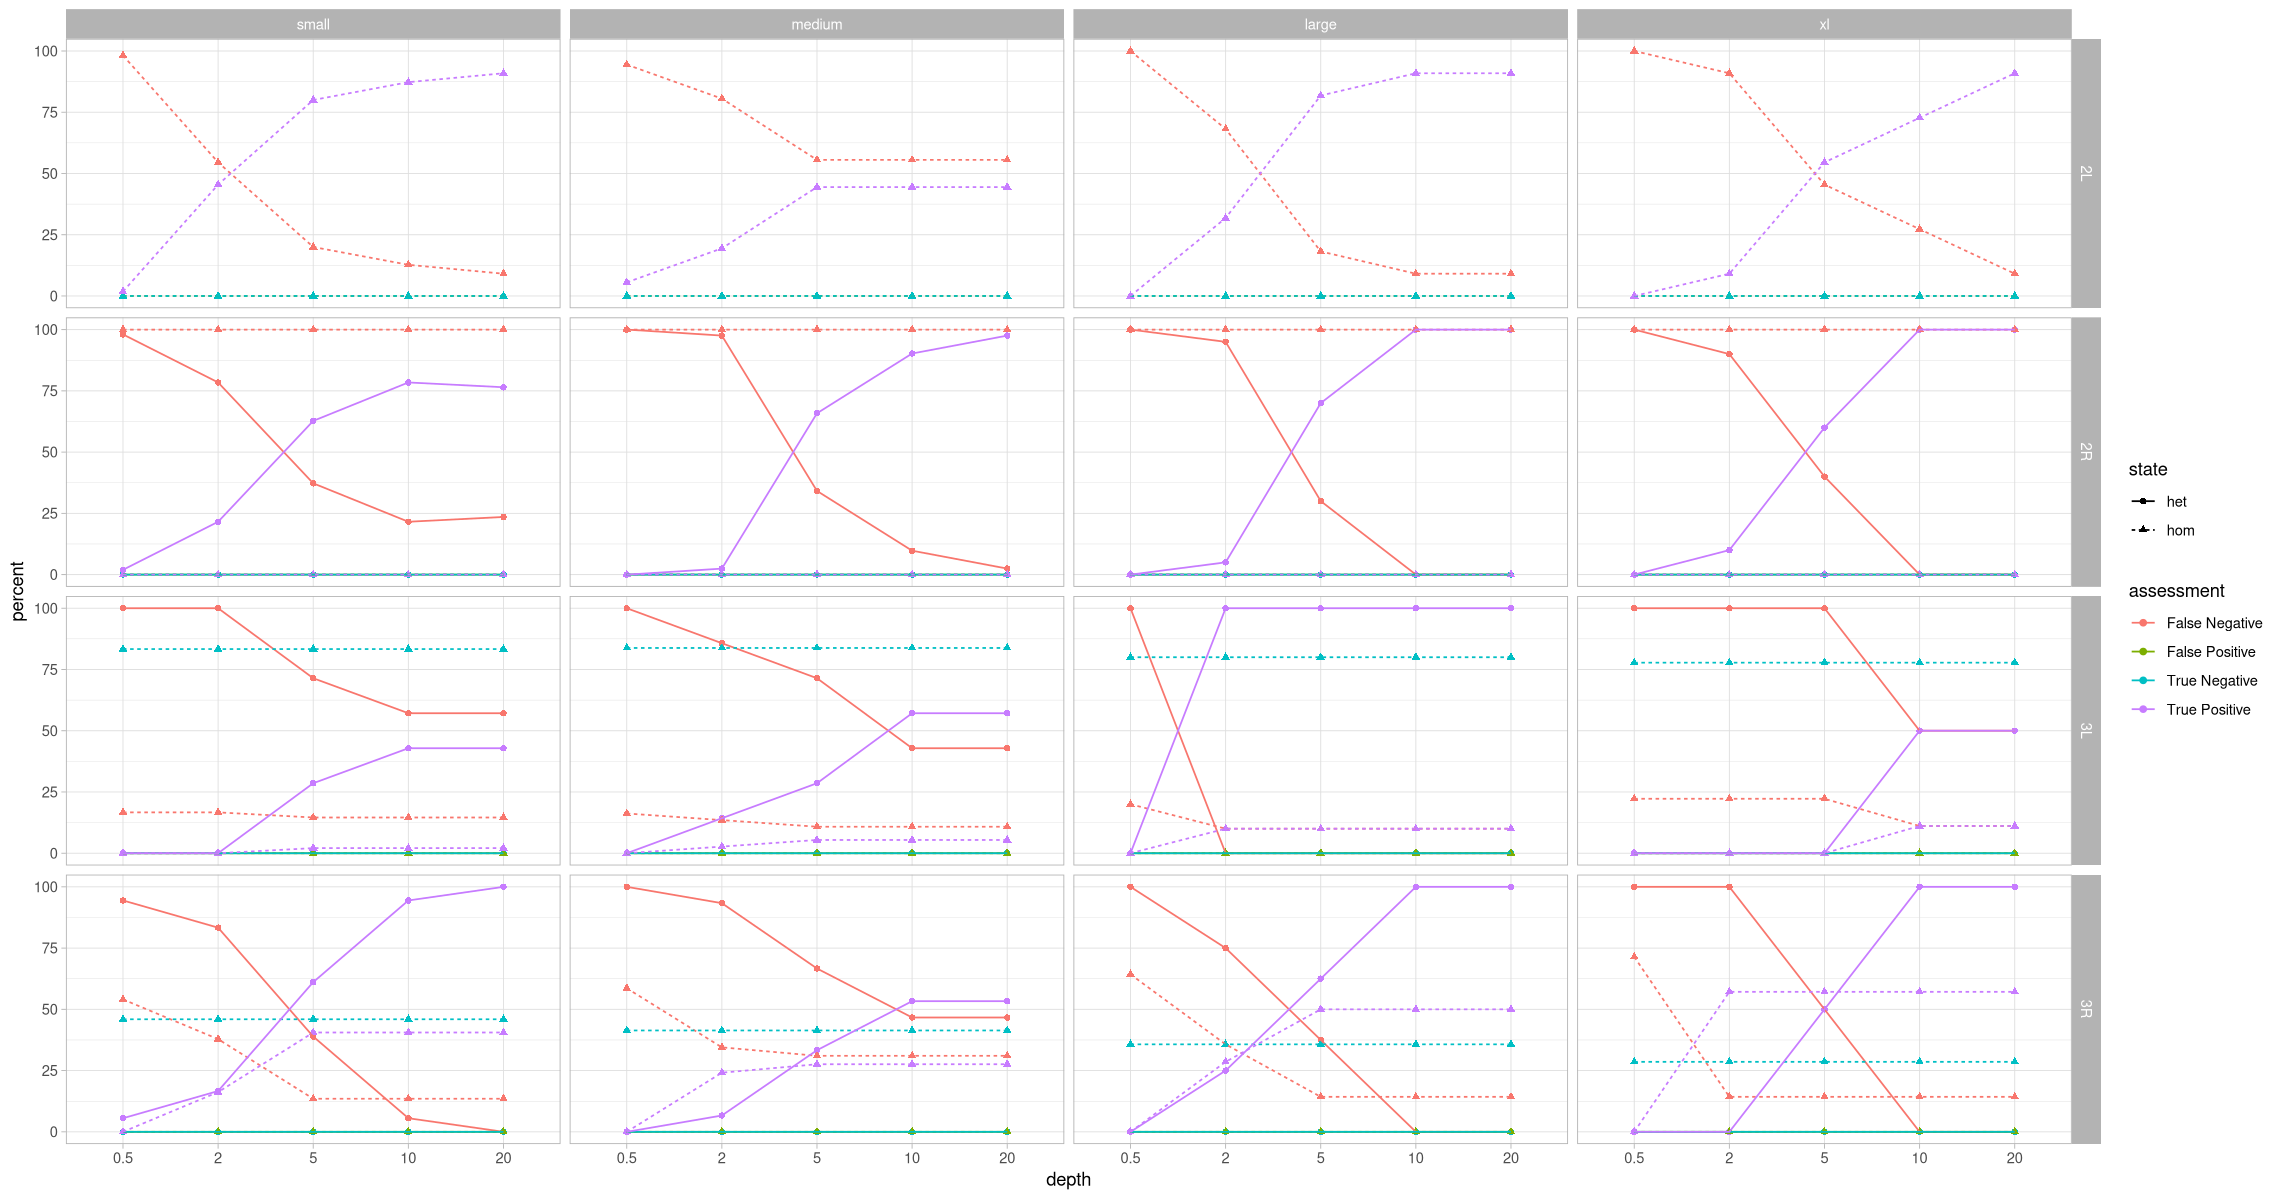

In [42]:
ggplot(assessment_by_contig_state, aes(x = depth, y = percent, color = assessment, shape = state, group = paste(assessment, state))) +
    geom_point() +
    geom_line(aes(linetype = state)) +
    theme_light() +
    facet_grid(rows = vars(contig), cols = vars(size))

## Splitting the positives and negatives
These plots don't communicate the situation necessarily accurately because there can be 75% true negatives of all possible states, but the true negative identification rate is actually 100%. So, let's split the data into samples that have an inversion simulated onto them and ones that done, then plot the positives separately from the negatives.

### Inversion was present

size,contig,depth,assessment,count,percent
<fct>,<chr>,<fct>,<chr>,<int>,<dbl>
small,2L,0.5,False Negative,54,98.181818
small,2L,0.5,True Positive,1,1.818182
small,2L,2,False Negative,30,54.545455
small,2L,2,True Positive,25,45.454545
small,2L,5,False Negative,11,20.000000
small,2L,5,True Positive,44,80.000000


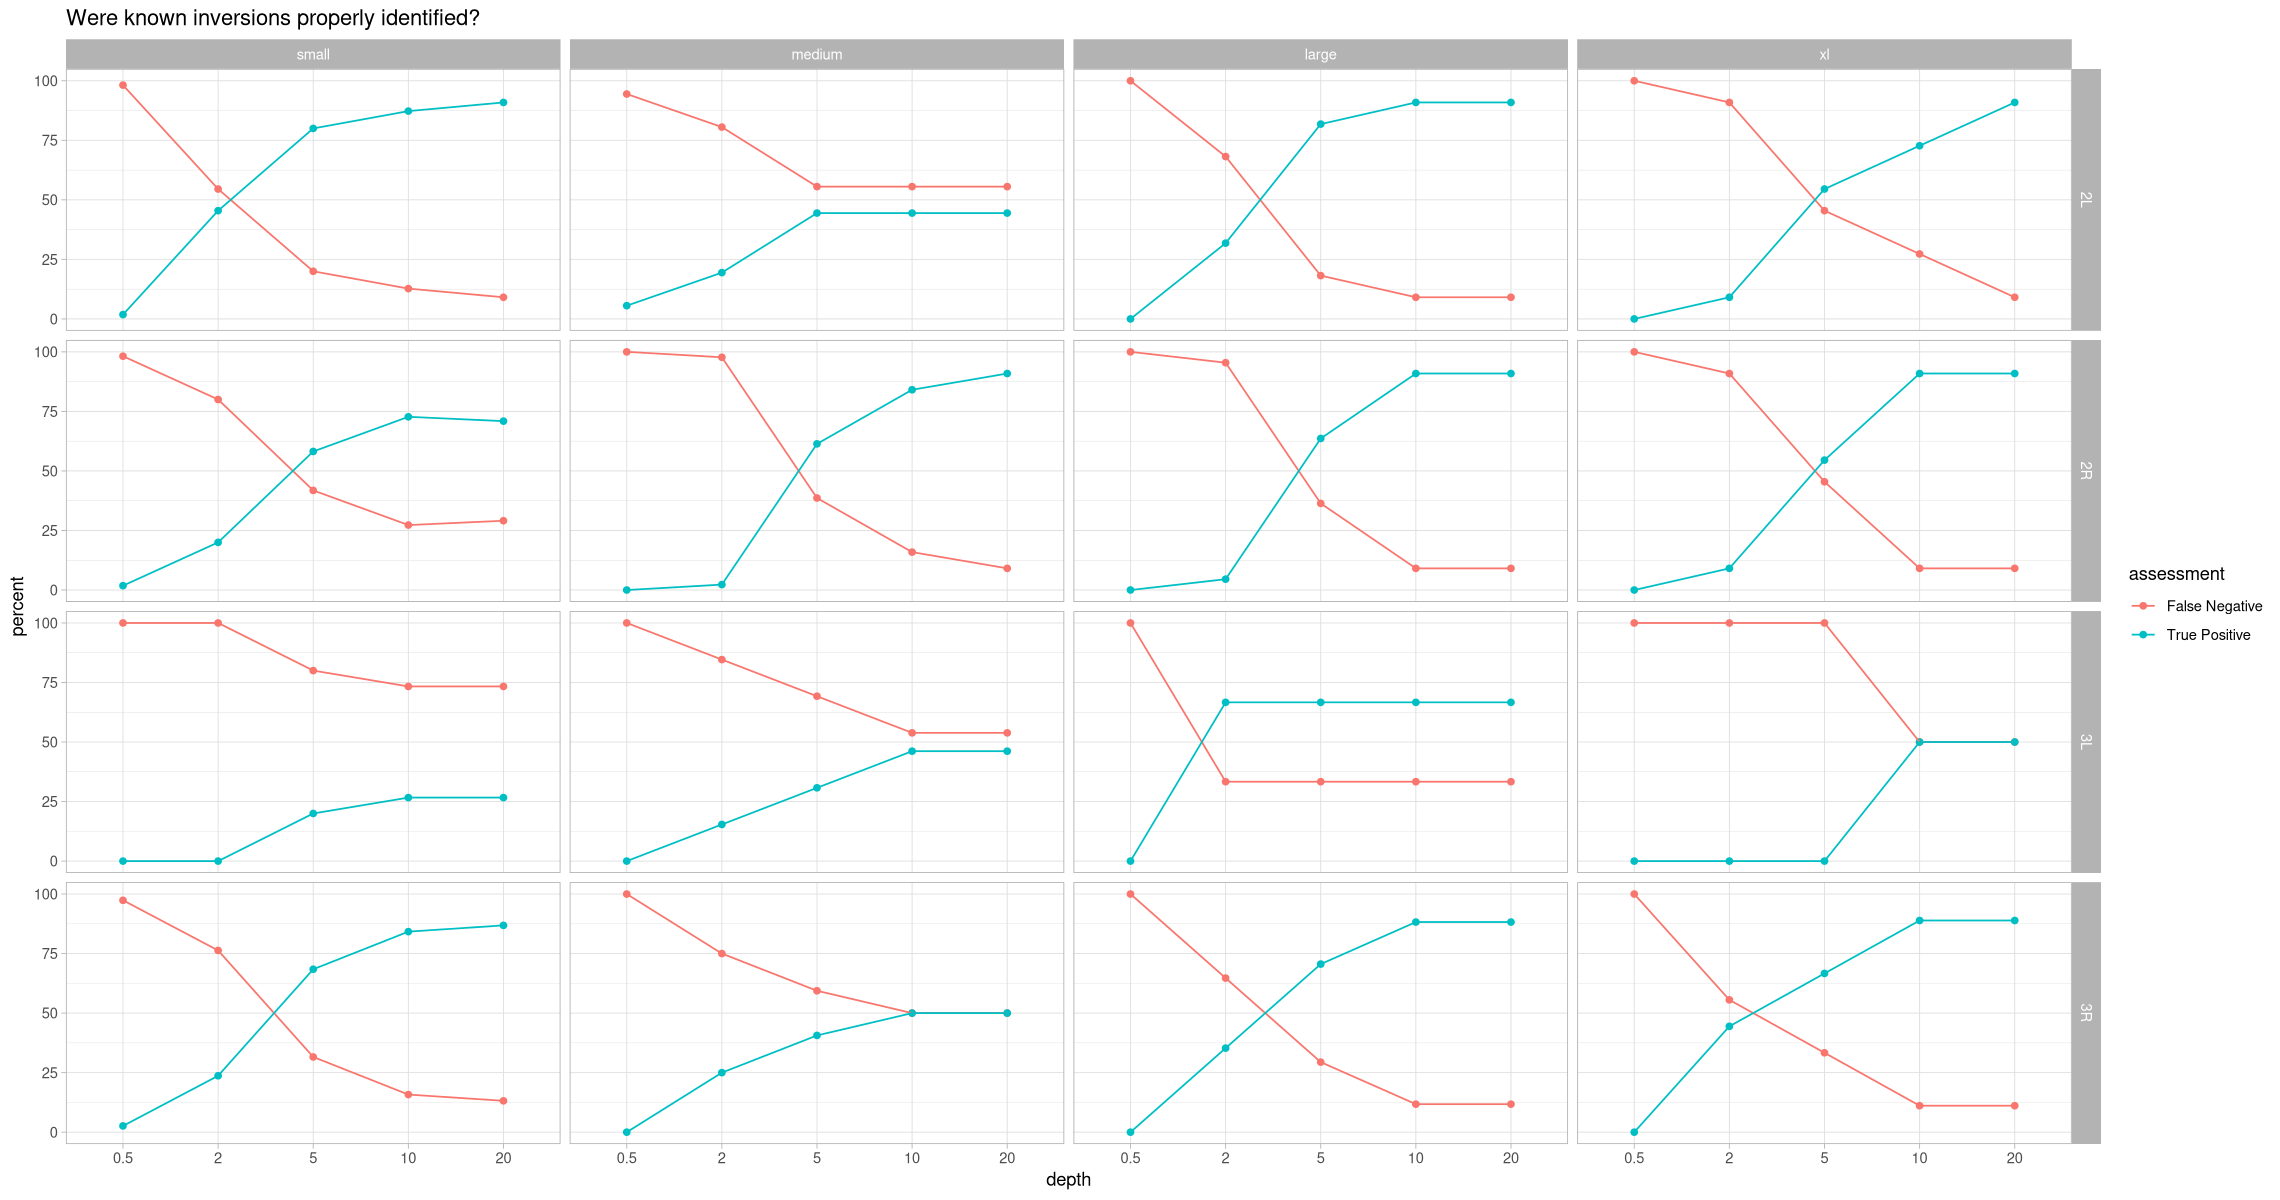

In [45]:
assessment_positive_contig <- filter(assessment, present, assessment %in% c("True Positive", "False Negative")) %>% group_by(size, contig, depth, assessment) %>% 
    summarize_at("count", ~ sum(.x)) %>%
    group_by(size, contig, depth) %>%
    mutate(percent = count/sum(count) * 100)
head(assessment_positive_contig)

ggplot(assessment_positive_contig, aes(x = depth, y = percent, color = assessment, group = assessment)) +
    geom_point() +
    geom_line() +
    theme_light() +
    labs(title = "Were known inversions properly identified?") +
    facet_grid(rows = vars(contig), cols = vars(size))

### Inversion was absent

In [46]:
assessment_negative_contig <- filter(assessment, !present, assessment %in% c("True Negative", "False Positive")) %>% group_by(size, contig, depth, assessment) %>% 
    summarize_at("count", ~ sum(.x)) %>%
    group_by(size, contig, depth, assessment) %>%
    mutate(percent = count/sum(count) * 100)

assessment_negative_contig$percent[is.na(assessment_negative_contig$percent)] <- 0
head(assessment_negative_contig)

size,contig,depth,assessment,count,percent
<fct>,<chr>,<fct>,<chr>,<int>,<dbl>
small,3L,0.5,False Positive,0,0
small,3L,0.5,True Negative,40,100
small,3L,2,False Positive,0,0
small,3L,2,True Negative,40,100
small,3L,5,False Positive,0,0
small,3L,5,True Negative,40,100


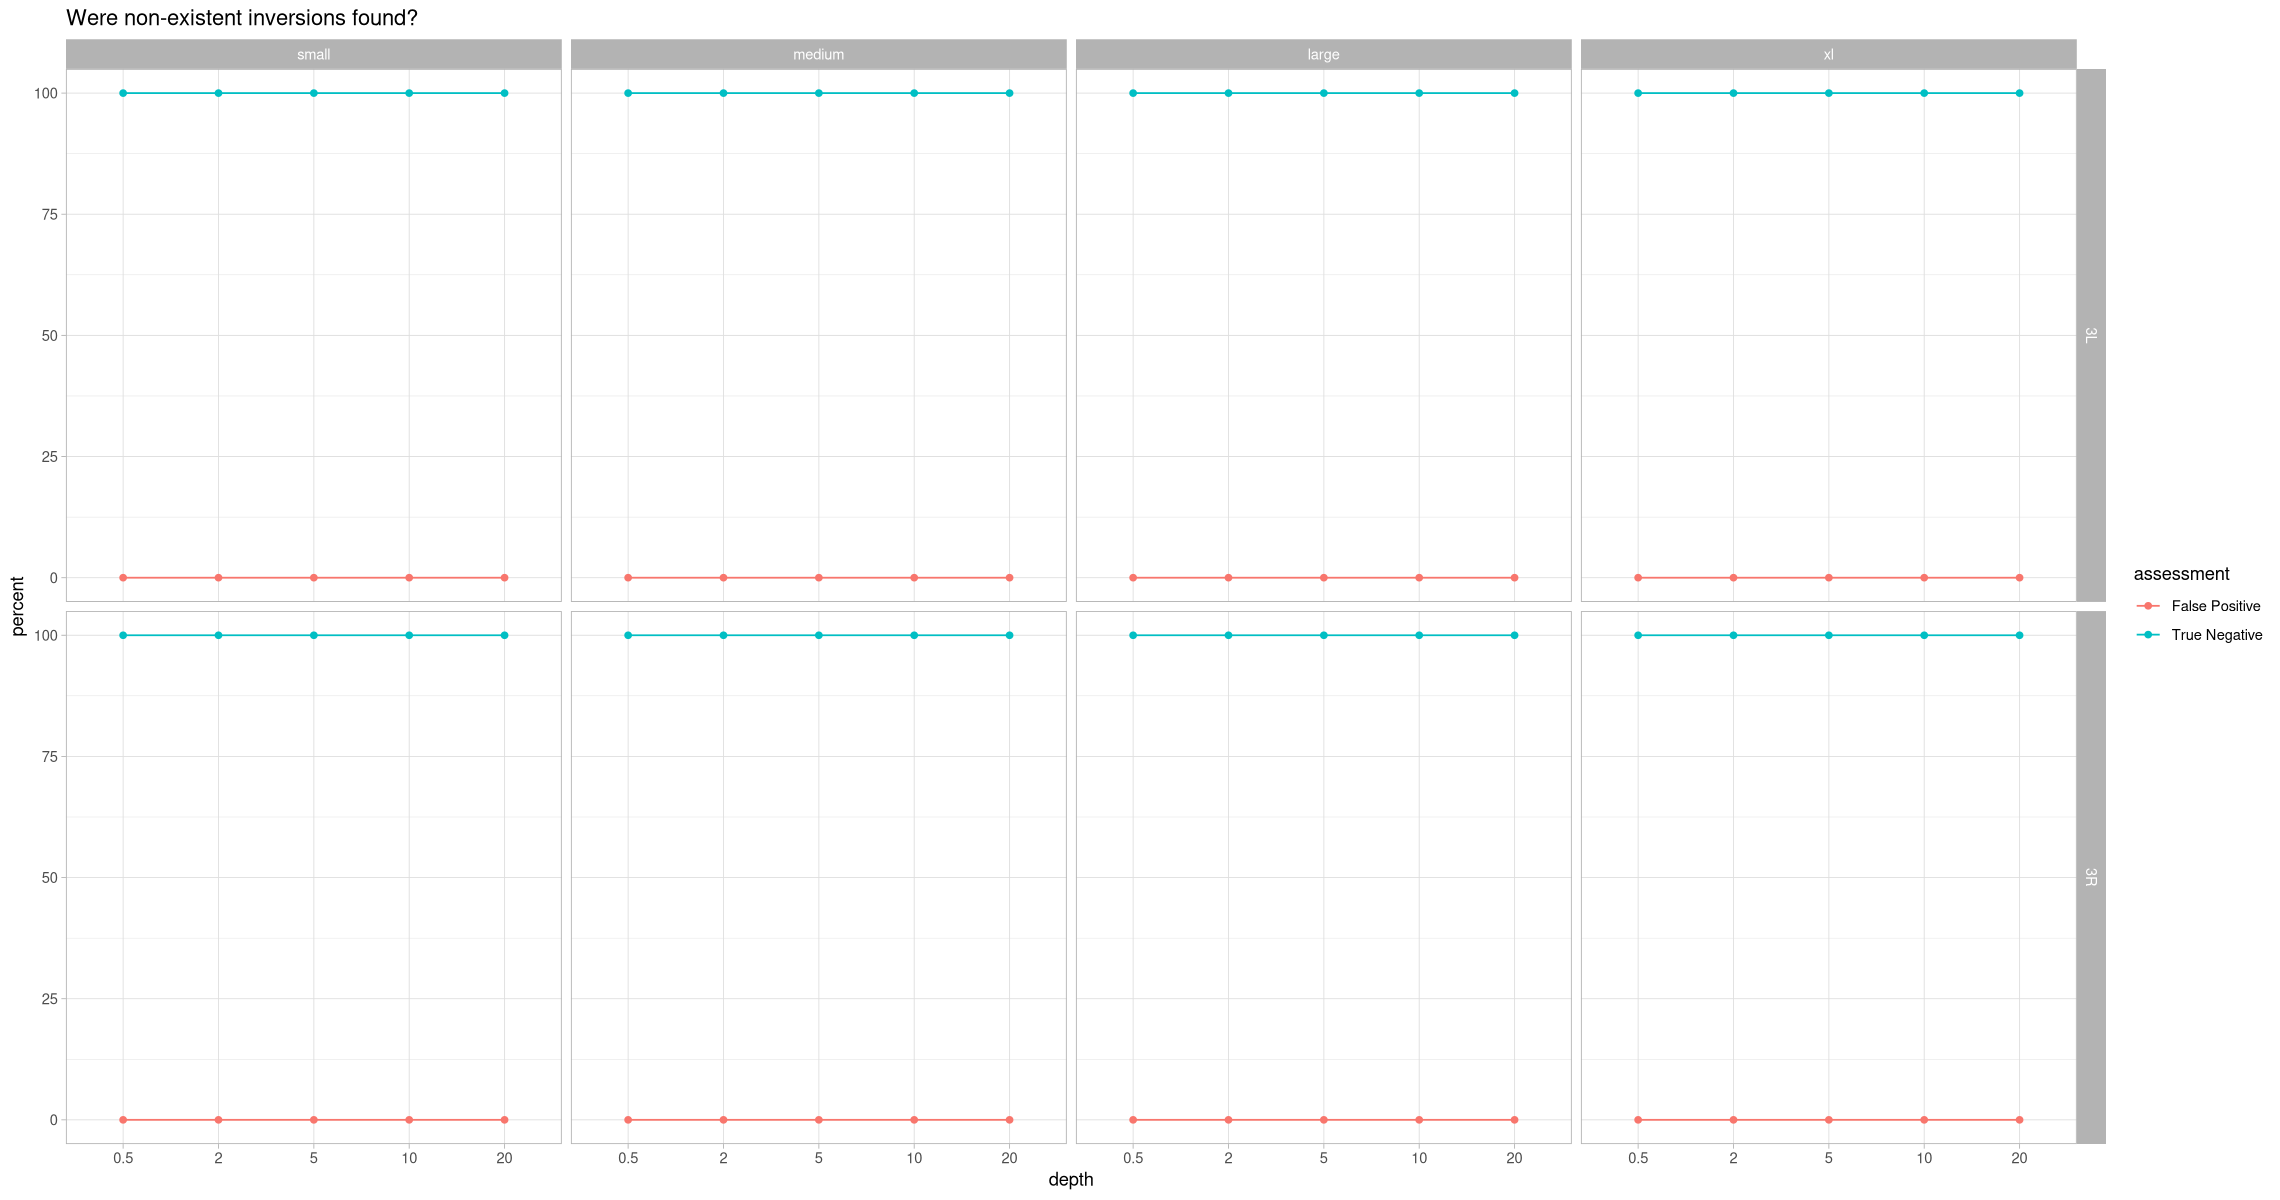

In [49]:

ggplot(assessment_negative_contig, aes(x = depth, y = percent, color = assessment, group = assessment)) +
    geom_point() +
    geom_line() +
    theme_light() +
    labs(title = "Were non-existent inversions found?") +
    facet_grid(rows = vars(contig), cols = vars(size))

In [50]:
head(assessment)

,sample,size,contig,id,present,state,position_start,position_end,depth,assessment,count
,<chr>,<fct>,<chr>,<int>,<lgl>,<chr>,<int>,<dbl>,<fct>,<chr>,<lgl>
1,sample_01,small,2R,1,TRUE,het,4328632,4333509,0.5,True Positive,FALSE
1.1,sample_01,small,2R,1,TRUE,het,4328632,4333509,0.5,False Positive,FALSE
1.2,sample_01,small,2R,1,TRUE,het,4328632,4333509,0.5,True Negative,FALSE
1.3,sample_01,small,2R,1,TRUE,het,4328632,4333509,0.5,False Negative,TRUE
2,sample_01,small,2R,2,TRUE,het,9952840,9959287,0.5,True Positive,FALSE
2.1,sample_01,small,2R,2,TRUE,het,9952840,9959287,0.5,False Positive,FALSE


### Inversion was present (zygosity)
Filter out the `pooled` samples as their zygosity messes up this plot

In [51]:
assessment_positive_contig_state <- filter(assessment, present, grepl("sample", sample), assessment %in% c("True Positive", "False Negative")) %>% group_by(size, state, contig, depth, assessment) %>% 
    summarize_at("count", ~ sum(.x)) %>%
    group_by(size, state, contig, depth) %>%
    mutate(percent = count/sum(count) * 100)
head(assessment_positive_contig_state)

size,state,contig,depth,assessment,count,percent
<fct>,<chr>,<chr>,<fct>,<chr>,<int>,<dbl>
small,het,2R,0.5,False Negative,49,98
small,het,2R,0.5,True Positive,1,2
small,het,2R,2,False Negative,39,78
small,het,2R,2,True Positive,11,22
small,het,2R,5,False Negative,18,36
small,het,2R,5,True Positive,32,64


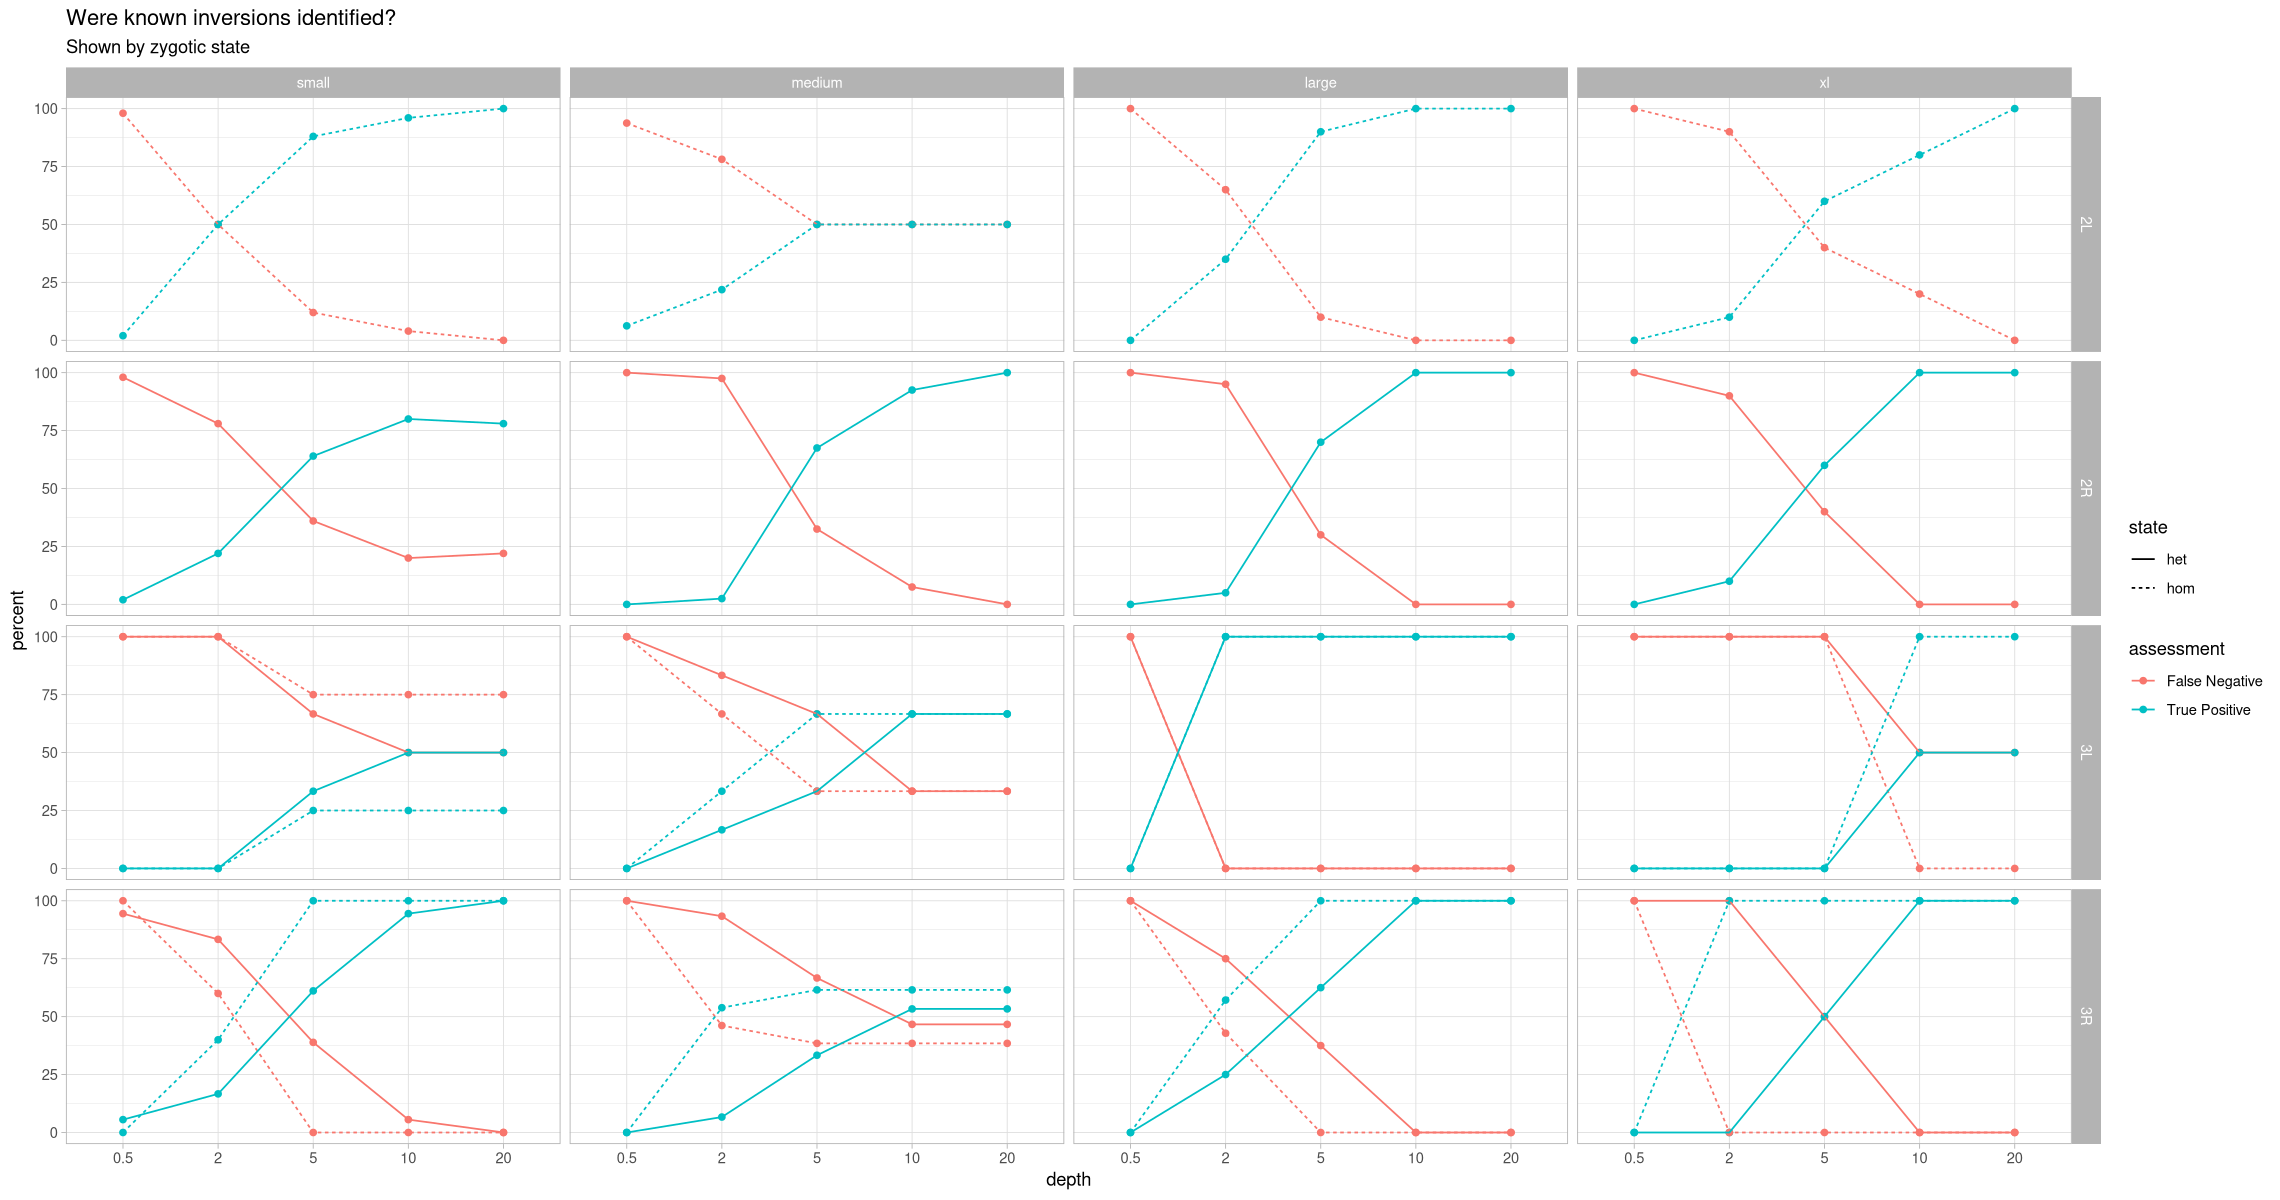

In [53]:
ggplot(assessment_positive_contig_state, aes(x = depth, y = percent, color = assessment, group = paste(assessment, state))) +
    geom_point() +
    geom_line(aes(linetype = state)) +
    theme_light() +
    labs(title = "Were known inversions identified?", subtitle = "Shown by zygotic state") +
    facet_grid(rows = vars(contig), cols = vars(size))